# Capítulo 8 · Épocas, batches y optimizadores

En los últimos capítulos seguimos una actualización individual: la red realiza una predicción, calcula la pérdida, obtiene gradientes mediante backpropagation y modifica sus parámetros. Un entrenamiento real organiza y repite ese ciclo muchas veces.

En este cuaderno veremos cómo las observaciones se agrupan en **batches**, cómo varias iteraciones forman una **epoch** y cómo un **optimizador** transforma los gradientes en actualizaciones. Finalmente abriremos la caja de `fit()` y compararemos, en un experimento controlado, diferentes tamaños de batch y los optimizadores SGD y Adam.

## Objetivos del cuaderno

Al finalizar este recorrido podrás:

- diferenciar batch, batch size, iteración y epoch;
- calcular cuántas actualizaciones produce una configuración de entrenamiento;
- observar cómo cambia la composición de los batches al mezclar los datos;
- interpretar la información que muestra `fit()`;
- comparar distintos valores de `batch_size` sobre una misma red;
- comparar SGD y Adam manteniendo constantes las demás decisiones principales;
- reconocer cómo influyen los datos, la red, las épocas y el hardware en el costo del entrenamiento.

## Importación de librerías

Usaremos NumPy y Pandas para organizar los datos, Matplotlib para las visualizaciones y TensorFlow/Keras para observar un entrenamiento real. El ejemplo es pequeño y puede ejecutarse con CPU; una GPU no es necesaria.

In [1]:
import os

# Reduce mensajes técnicos que no forman parte de la práctica.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

print(f"TensorFlow: {tf.__version__}")
print("GPU disponible:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU disponible: False


## 1. De una actualización a un entrenamiento

Un **batch** es el grupo de observaciones que la red procesa antes de actualizar sus parámetros. El **batch size** indica cuántos ejemplos contiene ese grupo. Una **iteración** corresponde al procesamiento de un batch y a la actualización asociada. Una **epoch** termina cuando el modelo utilizó una vez todas las observaciones de entrenamiento.

Si el dataset contiene $N$ ejemplos, la cantidad de batches por epoch puede calcularse con:

$$
\text{batches por epoch}
=
\left\lceil\frac{N}{\text{batch size}}\right\rceil
$$

El redondeo hacia arriba incluye un último batch incompleto cuando la división no es exacta.

In [2]:
cantidad_observaciones = 1000
epochs = 10
batch_sizes = [1, 32, 100, 1000]

filas = []

for batch_size in batch_sizes:
    batches_por_epoch = int(np.ceil(cantidad_observaciones / batch_size))
    ultimo_batch = cantidad_observaciones % batch_size or batch_size

    filas.append({
        "Batch size": batch_size,
        "Batches por epoch": batches_por_epoch,
        "Tamaño del último batch": ultimo_batch,
        "Actualizaciones en 10 epochs": batches_por_epoch * epochs,
    })

tabla_iteraciones = pd.DataFrame(filas)
display(tabla_iteraciones)

,Batch size,Batches por epoch,Tamaño del último batch,Actualizaciones en 10 epochs
0,1,1000,1,10000
1,32,32,8,320
2,100,10,100,100
3,1000,1,1000,10


Con `batch_size=1`, cada observación produce una actualización y diez recorridos generan 10 000 actualizaciones. Si usamos todo el dataset como un único batch, solo hay una actualización por epoch y diez en total.

Ninguna de estas cifras indica por sí sola qué configuración será mejor. Un batch pequeño ofrece actualizaciones más frecuentes y variables; uno grande agrega información de más observaciones, pero produce menos actualizaciones y exige más memoria por paso.

## 2. Cómo se forman los batches

Tomaremos doce observaciones y un `batch_size` de 4. Cada epoch tendrá tres batches. Antes de la segunda epoch mezclaremos el orden, tal como suele hacer Keras con datos tabulares cuando `shuffle=True`.

In [3]:
observaciones = np.arange(1, 13)
batch_size_ejemplo = 4
rng_batches = np.random.default_rng(8)

ordenes = {
    "Epoch 1": rng_batches.permutation(observaciones),
    "Epoch 2": rng_batches.permutation(observaciones),
}

filas_batches = []

for nombre_epoch, orden in ordenes.items():
    for numero_batch, inicio in enumerate(range(0, len(orden), batch_size_ejemplo), start=1):
        grupo = orden[inicio:inicio + batch_size_ejemplo]
        filas_batches.append({
            "Epoch": nombre_epoch,
            "Batch": numero_batch,
            "Observaciones": grupo.tolist(),
        })

display(pd.DataFrame(filas_batches))

,Epoch,Batch,Observaciones
0,Epoch 1,1,"[8, 4, 9, 1]"
1,Epoch 1,2,"[2, 11, 7, 12]"
2,Epoch 1,3,"[6, 10, 3, 5]"
3,Epoch 2,1,"[12, 9, 7, 6]"
4,Epoch 2,2,"[1, 2, 11, 8]"
5,Epoch 2,3,"[4, 10, 5, 3]"


Las dos epochs contienen las mismas doce observaciones, pero no necesariamente agrupadas de la misma forma. Como cada batch produce su propia pérdida y su propio gradiente, cambiar las combinaciones también modifica ligeramente las actualizaciones.

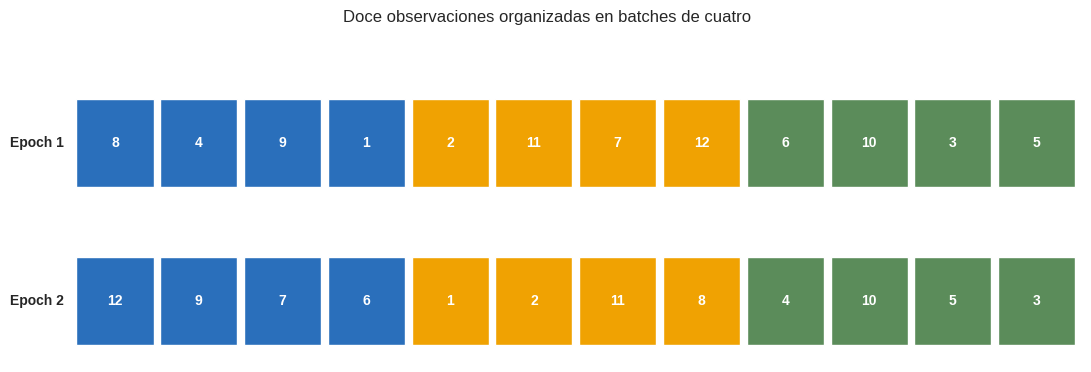

In [4]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 1, figsize=(11, 3.6))
colores = ["#2a6fbb", "#f0a202", "#5b8c5a"]

for ax, (nombre_epoch, orden) in zip(axes, ordenes.items()):
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 1)
    ax.axis("off")

    for posicion, observacion in enumerate(orden):
        numero_batch = posicion // batch_size_ejemplo
        rectangulo = Rectangle(
            (posicion, 0.12),
            0.92,
            0.62,
            facecolor=colores[numero_batch],
            edgecolor="white",
        )
        ax.add_patch(rectangulo)
        ax.text(
            posicion + 0.46,
            0.43,
            str(observacion),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )

    ax.text(-0.15, 0.43, nombre_epoch, ha="right", va="center", fontweight="bold")

fig.suptitle("Doce observaciones organizadas en batches de cuatro", y=1.02)
plt.tight_layout()
plt.show()

Cada color representa un batch y, por lo tanto, una iteración. Al finalizar los tres grupos se completa una epoch. La epoch siguiente empieza con los parámetros que resultaron de las tres actualizaciones anteriores.

Mezclar no siempre es apropiado: en datos temporales o secuenciales el orden puede contener información. En esta práctica trabajaremos con observaciones independientes.

## 3. Un pequeño laboratorio de entrenamiento

Para observar `fit()` necesitamos una red y algunos datos. Generaremos dos grupos de puntos con dos variables de entrada. El problema es deliberadamente sencillo: la red funcionará como un instrumento para estudiar el entrenamiento, no como el proyecto completo que construiremos en el capítulo siguiente.

Usaremos exactamente los mismos datos y la misma arquitectura en todos los experimentos.

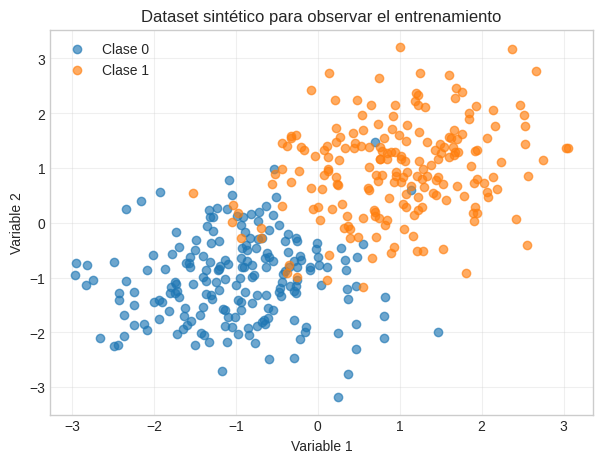

Forma de X: (400, 2)
Forma de y: (400,)


In [5]:
SEMILLA_DATOS = 42
rng = np.random.default_rng(SEMILLA_DATOS)

clase_0 = rng.normal(loc=(-1.0, -1.0), scale=0.85, size=(200, 2))
clase_1 = rng.normal(loc=(1.0, 1.0), scale=0.85, size=(200, 2))

X = np.vstack([clase_0, clase_1]).astype("float32")
y = np.concatenate([np.zeros(200), np.ones(200)]).astype("float32")

orden = rng.permutation(len(X))
X = X[orden]
y = y[orden]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.65, label="Clase 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.65, label="Clase 1")
ax.set_title("Dataset sintético para observar el entrenamiento")
ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

El dataset contiene 400 observaciones y dos clases equilibradas. Existe cierta superposición entre los grupos, de modo que una *accuracy* elevada no debe interpretarse como prueba de perfección ni como garantía sobre otros datos.

No realizaremos todavía un flujo completo de preparación, evaluación y análisis de errores. El objetivo de este capítulo es aislar las decisiones del entrenamiento.

## 4. La misma red para todos los experimentos

La arquitectura tendrá dos entradas, una capa oculta pequeña y una salida sigmoid. Para comparar configuraciones de manera razonable, reconstruiremos siempre la red con la misma semilla inicial.

La función `crear_modelo()` recibe un optimizador ya configurado. La pérdida y la métrica permanecen iguales en todos los casos.

In [6]:
SEMILLA_MODELO = 123

def crear_modelo(optimizador):
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEMILLA_MODELO)

    modelo = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    modelo.compile(
        optimizer=optimizador,
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return modelo

modelo_resumen = crear_modelo(
    keras.optimizers.Adam(learning_rate=0.01)
)

modelo_resumen.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

La red tiene 33 parámetros entrenables. No analizaremos nuevamente el conteo ni las activaciones porque ya fueron trabajados en capítulos anteriores. Aquí interesa observar cómo Keras organiza las actualizaciones de esos parámetros.

## 5. Qué muestra `fit()`

Entrenaremos una primera versión durante cinco epochs con `batch_size=32`. Como tenemos 400 observaciones, Keras procesará 13 batches por epoch: doce batches completos y uno con las 16 observaciones restantes.

Usamos `verbose=2` para mostrar una línea por epoch sin producir una salida excesivamente larga.

In [7]:
modelo_demo = crear_modelo(
    keras.optimizers.Adam(learning_rate=0.01)
)

historial_demo = modelo_demo.fit(
    X,
    y,
    epochs=5,
    batch_size=32,
    shuffle=True,
    verbose=2,
)

tabla_historial_demo = pd.DataFrame(historial_demo.history)
tabla_historial_demo.index = np.arange(1, len(tabla_historial_demo) + 1)
tabla_historial_demo.index.name = "Epoch"

display(tabla_historial_demo)

Epoch 1/5
13/13 - 1s - 98ms/step - accuracy: 0.8975 - loss: 0.4192
Epoch 2/5
13/13 - 0s - 6ms/step - accuracy: 0.9450 - loss: 0.2495
Epoch 3/5
13/13 - 0s - 5ms/step - accuracy: 0.9500 - loss: 0.1881
Epoch 4/5
13/13 - 0s - 5ms/step - accuracy: 0.9500 - loss: 0.1672
Epoch 5/5
13/13 - 0s - 5ms/step - accuracy: 0.9525 - loss: 0.1595


,accuracy,loss
Epoch,,
1,0.8975,0.4192
2,0.9450,0.2495
3,0.9500,0.1881
4,0.9500,0.1672
5,0.9525,0.1595


`Epoch 1/5` indica el primer recorrido completo por los datos. La salida `13/13` informa que se procesaron los trece batches previstos. `loss` resume la pérdida de entrenamiento y `accuracy` la proporción de clases acertadas.

Las cifras pueden variar ligeramente entre versiones de TensorFlow o tipos de hardware. Lo importante es la estructura: cada línea resume muchas iteraciones, y cada iteración contiene *forward pass*, pérdida, backpropagation y actualización.

### Cuando también hay datos de validación

Si proporcionamos datos de validación, Keras puede mostrar además `val_loss` y `val_accuracy`. Esos valores describen el comportamiento de la red sobre observaciones que no se utilizan para actualizar los parámetros.

La pérdida de entrenamiento participa directamente en backpropagation. `val_loss`, en cambio, sirve para observar el proceso desde fuera del conjunto utilizado para aprender. No agregaremos validación a esta comparación para mantener el foco en batches y optimizadores; retomaremos su interpretación al estudiar el comportamiento de una red completa.

## 6. Comparar diferentes batch sizes

Ahora entrenaremos cuatro copias de la misma red con Adam, el mismo *learning rate* y diez epochs. Solo cambiaremos `batch_size`.

Esta comparación requiere una precaución: igualar la cantidad de epochs no iguala la cantidad de actualizaciones. Con batches pequeños habrá muchas más iteraciones dentro de cada recorrido por los datos.

In [8]:
def entrenar_configuracion(batch_size, nombre_optimizador, epochs=10):
    if nombre_optimizador == "adam":
        optimizador = keras.optimizers.Adam(learning_rate=0.01)
    elif nombre_optimizador == "sgd":
        optimizador = keras.optimizers.SGD(learning_rate=0.01)
    else:
        raise ValueError("Optimizador no reconocido")

    modelo = crear_modelo(optimizador)

    inicio = time.perf_counter()
    historial = modelo.fit(
        X,
        y,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        verbose=0,
    )
    duracion = time.perf_counter() - inicio

    return historial.history, duracion


batch_sizes_experimento = [1, 16, 64, len(X)]
historiales_batch = {}
resumen_batch = []
epochs_batch = 10

for batch_size in batch_sizes_experimento:
    historial, duracion = entrenar_configuracion(
        batch_size=batch_size,
        nombre_optimizador="adam",
        epochs=epochs_batch,
    )

    batches_por_epoch = int(np.ceil(len(X) / batch_size))
    historiales_batch[batch_size] = historial
    resumen_batch.append({
        "Batch size": batch_size,
        "Batches por epoch": batches_por_epoch,
        "Actualizaciones estimadas": batches_por_epoch * epochs_batch,
        "Loss final": historial["loss"][-1],
        "Accuracy final": historial["accuracy"][-1],
        "Tiempo en esta ejecución (s)": duracion,
    })

resumen_batch = pd.DataFrame(resumen_batch)
display(resumen_batch)

,Batch size,Batches por epoch,Actualizaciones estimadas,Loss final,Accuracy final,Tiempo en esta ejecución (s)
0,1,400,4000,0.1642,0.9500,7.2134
1,16,25,250,0.1543,0.9500,1.7167
2,64,7,70,0.1564,0.9550,2.3723
3,400,1,10,0.3487,0.9275,1.2761


Las configuraciones recorrieron los mismos datos diez veces, pero realizaron cantidades de actualizaciones muy diferentes. `batch_size=1` produjo 4000 actualizaciones; usar las 400 observaciones juntas produjo solamente 10.

El tiempo es orientativo y cambiará según la CPU, GPU, versión de TensorFlow y carga del entorno. Tampoco debemos elegir una configuración basándonos únicamente en la menor pérdida de este pequeño experimento.

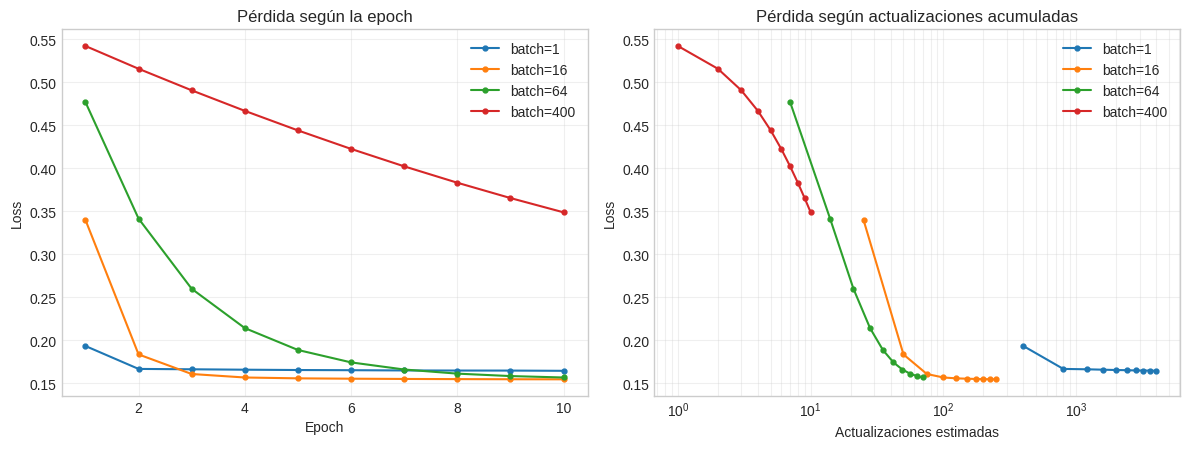

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for batch_size, historial in historiales_batch.items():
    epochs_eje = np.arange(1, epochs_batch + 1)
    batches_por_epoch = int(np.ceil(len(X) / batch_size))
    actualizaciones_eje = epochs_eje * batches_por_epoch

    axes[0].plot(
        epochs_eje,
        historial["loss"],
        marker="o",
        markersize=3.5,
        label=f"batch={batch_size}",
    )
    axes[1].plot(
        actualizaciones_eje,
        historial["loss"],
        marker="o",
        markersize=3.5,
        label=f"batch={batch_size}",
    )

axes[0].set_title("Pérdida según la epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Pérdida según actualizaciones acumuladas")
axes[1].set_xlabel("Actualizaciones estimadas")
axes[1].set_ylabel("Loss")
axes[1].set_xscale("log")
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

El gráfico izquierdo compara recorridos completos por los datos. El derecho recuerda que una epoch puede contener una cantidad muy distinta de actualizaciones según el batch size.

Los batches pequeños introducen gradientes más variables y realizan más correcciones. Los grandes producen menos actualizaciones y agregan información de más ejemplos en cada una. El experimento muestra el compromiso; no establece un ganador universal.

## 7. Comparar SGD y Adam

Mantendremos la arquitectura, los datos, el batch size, la cantidad de epochs y el *learning rate* en `0.01`. Solo cambiaremos el optimizador.

SGD utiliza directamente el gradiente del batch para realizar la actualización. Adam conserva información sobre gradientes recientes y adapta internamente la escala aplicada a cada parámetro. No desarrollaremos aquí su formulación completa: el capítulo busca comprender su función dentro del entrenamiento.

En sentido estricto, el nombre *stochastic gradient descent* se aplicaba a actualizaciones basadas en una sola observación. En Deep Learning también es habitual llamar SGD al mismo optimizador cuando trabaja con mini-batches, como haremos aquí con grupos de 32 ejemplos.

In [10]:
optimizadores = ["sgd", "adam"]
historiales_optimizador = {}
resumen_optimizadores = []
epochs_optimizador = 20
batch_size_optimizador = 32

for nombre in optimizadores:
    historial, duracion = entrenar_configuracion(
        batch_size=batch_size_optimizador,
        nombre_optimizador=nombre,
        epochs=epochs_optimizador,
    )

    historiales_optimizador[nombre] = historial
    resumen_optimizadores.append({
        "Optimizador": nombre.upper(),
        "Learning rate": 0.01,
        "Loss final": historial["loss"][-1],
        "Accuracy final": historial["accuracy"][-1],
        "Tiempo en esta ejecución (s)": duracion,
    })

display(pd.DataFrame(resumen_optimizadores))

,Optimizador,Learning rate,Loss final,Accuracy final,Tiempo en esta ejecución (s)
0,SGD,0.0100,0.2419,0.9475,1.6922
1,ADAM,0.0100,0.1534,0.9500,2.1376


En esta ejecución Adam suele reducir la pérdida con mayor rapidez durante las primeras epochs. Ese resultado pertenece a esta red, estos datos y esta configuración. No demuestra que Adam sea siempre superior a SGD.

El optimizador no cambia qué significa equivocarse: ambos modelos siguen utilizando `binary_crossentropy`. Lo que cambia es la estrategia aplicada a los gradientes.

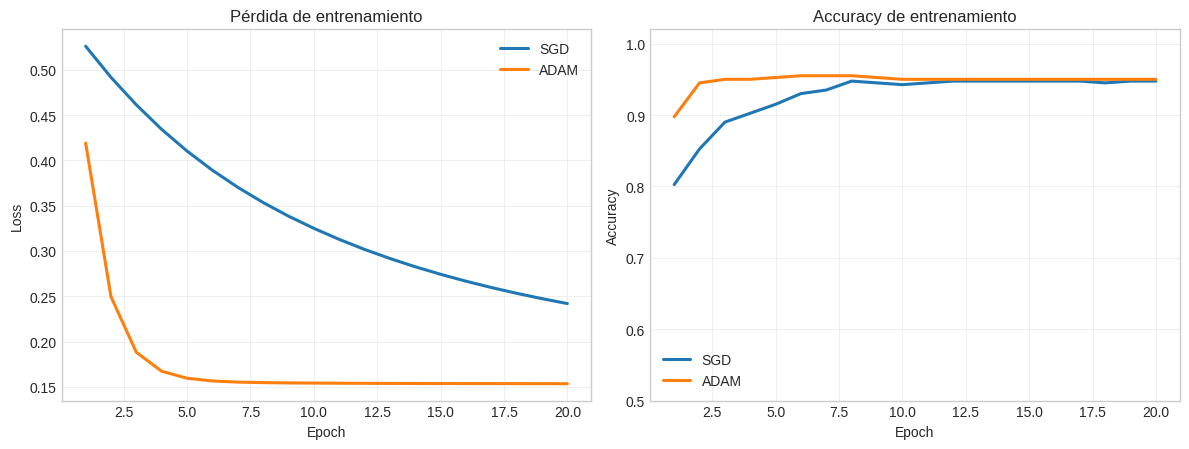

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for nombre, historial in historiales_optimizador.items():
    eje_epochs = np.arange(1, epochs_optimizador + 1)
    etiqueta = nombre.upper()

    axes[0].plot(eje_epochs, historial["loss"], linewidth=2.2, label=etiqueta)
    axes[1].plot(eje_epochs, historial["accuracy"], linewidth=2.2, label=etiqueta)

axes[0].set_title("Pérdida de entrenamiento")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Accuracy de entrenamiento")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.5, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas permiten observar el proceso completo y no solo el resultado final. Una configuración puede mejorar rápido al principio y estabilizarse después; otra puede avanzar más lentamente.

Una *accuracy* alta sobre los mismos datos usados para entrenar no constituye una evaluación completa. En capítulos posteriores volveremos sobre validación, generalización y análisis de errores.

## 8. Qué controla `compile()` y qué controla `fit()`

Las dos instrucciones cumplen funciones diferentes:

```python
modelo.compile(
    optimizer=optimizador,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
```

`compile()` especifica la pérdida que queremos minimizar, el optimizador que utilizará los gradientes y las métricas que deseamos observar.

```python
modelo.fit(
    X,
    y,
    epochs=20,
    batch_size=32,
    shuffle=True
)
```

`fit()` organiza la repetición del ciclo sobre los datos. En cada batch realiza el *forward pass*, calcula la pérdida, ejecuta backpropagation y aplica el optimizador. Al terminar todos los batches completa una epoch.

## 9. Costo de entrenamiento y aceleradores

El tiempo de entrenamiento depende de la cantidad de datos, el batch size, las epochs, la arquitectura y el hardware. Un batch grande puede aprovechar mejor operaciones paralelas, pero requiere más memoria. Un batch pequeño necesita menos memoria por paso, aunque produce más iteraciones.

La primera celda informó si este entorno detectó una GPU. El resultado puede cambiar al ejecutar el cuaderno en Colab y seleccionar un acelerador. Esta red es tan pequeña que una CPU resulta suficiente; usar GPU no garantiza una mejora perceptible en ejemplos mínimos.

Colab también puede ofrecer TPU, aceleradores especializados para cargas de Machine Learning. Su configuración y aprovechamiento dependen del tipo de modelo; no son necesarios para este cuaderno.

Tampoco existe una relación exacta donde duplicar el batch size reduzca el tiempo a la mitad. La preparación de datos, la compilación de operaciones y las características del hardware también influyen.

## 10. Más epochs no significan automáticamente un modelo mejor

Repetir el recorrido por los datos puede seguir reduciendo la pérdida de entrenamiento, pero no garantiza una mejora sobre observaciones nuevas. Si entrenamos durante demasiado tiempo, la red puede adaptarse en exceso a particularidades del conjunto utilizado para aprender.

En un entrenamiento con validación podríamos observar que `loss` continúa bajando mientras `val_loss` comienza a aumentar. Esa separación puede ser una señal de sobreajuste. La cantidad de epochs es, por lo tanto, otro hiperparámetro y no una medida directa de calidad.

Más adelante estudiaremos estrategias para detectar ese comportamiento y decidir cuándo detener el entrenamiento. En este capítulo alcanza con conservar una idea prudente: aumentar las epochs también aumenta el costo y no garantiza por sí solo un modelo mejor.

## 11. Actividad breve

La siguiente celda permite elegir un optimizador, un batch size y una cantidad de epochs. Modificá una sola variable por vez para que la comparación resulte interpretable.

El tiempo y las cifras obtenidas pueden variar entre ejecuciones. Registrá la cantidad estimada de actualizaciones junto con la pérdida y la *accuracy* final.

In [12]:
# Modificá una configuración por vez y volvé a ejecutar la celda.
optimizador_actividad = "adam"   # "adam" o "sgd"
batch_size_actividad = 32
epochs_actividad = 8

historial_actividad, tiempo_actividad = entrenar_configuracion(
    batch_size=batch_size_actividad,
    nombre_optimizador=optimizador_actividad,
    epochs=epochs_actividad,
)

batches_actividad = int(np.ceil(len(X) / batch_size_actividad))

resultado_actividad = pd.DataFrame({
    "Optimizador": [optimizador_actividad.upper()],
    "Batch size": [batch_size_actividad],
    "Epochs": [epochs_actividad],
    "Actualizaciones estimadas": [batches_actividad * epochs_actividad],
    "Loss final": [historial_actividad["loss"][-1]],
    "Accuracy final": [historial_actividad["accuracy"][-1]],
    "Tiempo (s)": [tiempo_actividad],
})

display(resultado_actividad)

,Optimizador,Batch size,Epochs,Actualizaciones estimadas,Loss final,Accuracy final,Tiempo (s)
0,ADAM,32,8,104,0.1547,0.9550,1.3540


La configuración inicial utiliza Adam, batches de 32 observaciones y ocho epochs. El propósito de la actividad no es encontrar “la mejor” combinación mediante pruebas indiscriminadas, sino formular una comparación concreta y modificar un solo factor por vez.

## Cierre

En este cuaderno organizamos las actualizaciones individuales estudiadas en los capítulos anteriores dentro de un entrenamiento real. Un batch reúne los ejemplos procesados antes de una actualización; una iteración corresponde a ese procesamiento y su actualización; una epoch termina cuando se utiliza una vez todo el conjunto de entrenamiento.

También comprobamos que el batch size modifica la cantidad de actualizaciones y la forma en que se estiman los gradientes. Después comparamos SGD y Adam sobre la misma red: ambos reciben gradientes calculados por backpropagation, pero los convierten en actualizaciones mediante estrategias diferentes.

Finalmente interpretamos `compile()` y `fit()` como coordinadores de mecanismos que ya conocemos. Con esto cerramos el recorrido sobre **cómo aprende una red neuronal**. En el capítulo siguiente utilizaremos estas piezas para construir y entrenar nuestra primera red completa dentro de un flujo práctico.

## Para pensar

1. ¿Por qué diez epochs no implican la misma cantidad de actualizaciones para todos los batch sizes?
2. ¿Qué parte del entrenamiento permanece igual cuando cambiamos SGD por Adam?
3. ¿Por qué el menor tiempo o la mayor *accuracy* de una única ejecución no alcanzan para elegir una configuración universalmente mejor?

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
